<a href="https://colab.research.google.com/github/JuliaZyrianova/coffee-shop-sales-analysis/blob/main/%D0%A1%D1%82%D0%B0%D0%B6%D0%B8%D1%80%D0%BE%D0%B2%D0%BA%D0%B0%D0%A2%D0%93%D0%A3_%22%D0%B8%D1%82%D0%BE%D0%B3%D0%BE%D0%B2%D0%BE%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Описание кейса**

![](https://avatars.mds.yandex.net/i?id=829986cbb58dd9b5f0335df83482c05d_l-5210052-images-thumbs&n=13)
<font color="grey" size="1"><a href="https://ru.freepik.com/free-vector/gamers-using-different-devices-and-playing-on-mobile-phone-tablet-laptop-console-cartoon-illustration_12699087.htm#query=gamers-using-different-devices&position=0&from_view=search&track=sph">Изображение от pch.vector на Freepik</a></font>

> Для расширения сети кофеен необходимо проанализировать распределение продаж по сети, продажи в разрезе категорий продукции, а также целевую аудиторию кофеен, чтобы сформировать рекомендации по развитию сети.
<br> Заказчиком предоставлен датасет с выгруженной информацией о транзакциях, товарах и клиентах из CRM-системы в формате CSV.

**Наша задача** — проанализировать полученные данные и представить аналитический отчет, содержащий выводы и рекомендации для Заказчика, которые помогут ему для решения своих бизнес-задач.

Какая **информация важна** для анализа:
1. идентификатор транзакции (transaction_id)
2. количество единиц товара (quantity)
3. цена за единицу товара (unit_price)
4. информация о товаре (product_info), в т.ч. идентификатор товара (product_id),
наименование товара (product_name), категория товара (product_category)
5. информация о кофейне (store_info), в т.ч. идентификатор кофейни
(sales_outlet_id), город расположения кофейни (store_city)
6. информация о покупателях (customer_info), в т.ч. идентификатор покупателя
(customer_id), дата рождения (birthdate), пол (gender)
7. общая сумма чека (total)

**Формат файла** по результатам предобработки: *xlsx* или *csv*

# **Изучение данных**

In [ ]:
# из библиотеки google.colab импортируем класс files при необходимости подгрузки файла с персонального компьютера
from google.colab import files
# импортируем pandas - основную библиотеку аналитика данных
import pandas as pd
# импортируем библиотеку numpy для возможных расчетов
import numpy as np
# импортируем модуль json для распаковки структур данных формата json
import json
# импортируем статистические библиотеки
import scipy
import scipy.stats as stats
# импортируем модуль pyplot из библиотеки matplotlib для визуализации
from matplotlib import pyplot as plt
# импортируем библиотеку seaborn для визуализации
import seaborn as sns

In [ ]:
# установить размер графиков
sns.set(rc={'figure.figsize':(8,4)})

In [ ]:
uploaded = files.upload()

Saving coffee_shop_hard.csv to coffee_shop_hard.csv


In [ ]:
df = pd.read_csv('coffee_shop_hard.csv')

## Обзор датасета

In [ ]:
df.head()

,transaction_id,quantity,unit_price,product_info,store_info,customer_info
0,0,1,162.50,"{""product_id"":52,""product_name"":""Traditional B...","{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":558,""birthdate"":""1983-02-25"",""g..."
1,1,2,227.50,"{""product_id"":27,""product_name"":""Brazilian Lg""...","{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":781,""birthdate"":""1991-07-29"",""g..."
2,2,2,162.50,"{""product_id"":46,""product_name"":""Serenity Gree...","{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":788,""birthdate"":""1995-02-23"",""g..."
3,3,2,162.50,"{""product_id"":23,""product_name"":""Our Old Time ...","{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":683,""birthdate"":""1999-02-06"",""g..."
4,4,1,159.25,"{""product_id"":34,""product_name"":""Jamaican Coff...","{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":99,""birthdate"":""1967-01-29"",""ge..."


In [ ]:
df.shape

(24909, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24909 entries, 0 to 24908
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  24909 non-null  int64  
 1   quantity        24909 non-null  int64  
 2   unit_price      24909 non-null  float64
 3   product_info    24909 non-null  object 
 4   store_info      24909 non-null  object 
 5   customer_info   24909 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 1.1+ MB


## Выявление проблем

1. Необходимость в распаковке вложенных структур данных ('product_info', 'store_info', 'customer_info')
2. Наличие признаков, не представляющих ценности в рамках кейса (product_id?, product_name?). В первую очередь нас интересует, какие группы (категории) товаров приносят больше всего дохода. Поэтому product_category — это ключевое поле. product_name и product_id могут потребоваться для более глубокого анализа и детализации, но в первую очередь нужно понять, что происходит на уровне категорий.
3. Возможно наличие дубликатов
4. Приведение признаков в необходимый формат (в datetime: 'birthdate')
5. Необходимость расчета признака 'age' (от признака 'birthdate')
6. Необходимость рассчитать общую сумму чека total, используя известные:

  количество единиц товара (quantity)

  цена за единицу товара (unit_price)

7. Возможные другие проблемы, которые могут быть выявлены в процессе предобработки данных

# **Предобработка данных**

## Проверка и исключение дубликатов

In [ ]:
df_copy = df.copy()

In [ ]:
df_copy.columns

Index(['transaction_id', 'quantity', 'unit_price', 'product_info',
       'store_info', 'customer_info'],
      dtype='object')

In [ ]:
df_copy.duplicated().sum()

np.int64(57)

In [ ]:
# проверка дубликатов по столбцу transaction_id
df_copy.duplicated(subset='transaction_id').sum()

np.int64(57)

In [ ]:
# исключение дубликатов по всем признакам датафрейма
df_copy.drop_duplicates(inplace=True)

In [ ]:
# контроль размеров датафрейма
df_copy.shape

(24852, 6)

## Распаковка вложенных структур данных

In [ ]:
df_copy.head(3)

,transaction_id,quantity,unit_price,product_info,store_info,customer_info
0,0,1,162.5,"{""product_id"":52,""product_name"":""Traditional B...","{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":558,""birthdate"":""1983-02-25"",""g..."
1,1,2,227.5,"{""product_id"":27,""product_name"":""Brazilian Lg""...","{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":781,""birthdate"":""1991-07-29"",""g..."
2,2,2,162.5,"{""product_id"":46,""product_name"":""Serenity Gree...","{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":788,""birthdate"":""1995-02-23"",""g..."


**Необходимо обработать:** 'product_info', 'store_info', 'customer_info'

### 'product_info'

In [ ]:
# обзор значения по признаку
df_copy['product_info'][0]

'{"product_id":52,"product_name":"Traditional Blend Chai Rg","product_category":"Tea"}'

In [ ]:
def unpack_product_info(product_info_str):
    if isinstance(product_info_str, str):
        product_info = json.loads(product_info_str)
    elif isinstance(product_info_str, dict):
        product_info = product_info_str
    else:
        return pd.Series([None, None, None], index=['product_id', 'product_name', 'product_category'])

    return pd.Series([product_info.get("product_id"), product_info.get("product_name"), product_info.get("product_category")], index=['product_id', 'product_name', 'product_category'])

In [ ]:
# применяем функцию к столбцу
df_copy[['product_id', 'product_name', 'product_category']] = df_copy['product_info'].apply(unpack_product_info)

In [ ]:
# контроль результата
df_copy

,transaction_id,quantity,unit_price,product_info,store_info,customer_info,product_id,product_name,product_category
0,0,1,162.50,"{""product_id"":52,""product_name"":""Traditional B...","{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":558,""birthdate"":""1983-02-25"",""g...",52,Traditional Blend Chai Rg,Tea
1,1,2,227.50,"{""product_id"":27,""product_name"":""Brazilian Lg""...","{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":781,""birthdate"":""1991-07-29"",""g...",27,Brazilian Lg,Coffee
2,2,2,162.50,"{""product_id"":46,""product_name"":""Serenity Gree...","{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":788,""birthdate"":""1995-02-23"",""g...",46,Serenity Green Tea Rg,Tea
3,3,2,162.50,"{""product_id"":23,""product_name"":""Our Old Time ...","{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":683,""birthdate"":""1999-02-06"",""g...",23,Our Old Time Diner Blend Rg,Coffee
4,4,1,159.25,"{""product_id"":34,""product_name"":""Jamaican Coff...","{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":99,""birthdate"":""1967-01-29"",""ge...",34,Jamaican Coffee River Sm,Coffee
...,...,...,...,...,...,...,...,...,...
24847,49882,1,276.25,"{""product_id"":41,""product_name"":""Cappuccino Lg...","{""sales_outlet_id"":8,""store_city"":""Moscow""}","{""customer_id"":8026,""birthdate"":""1962-10-25"",""...",41,Cappuccino Lg,Coffee
24848,49888,1,136.50,"{""product_id"":87,""product_name"":""Ouro Brasilei...","{""sales_outlet_id"":8,""store_city"":""Moscow""}","{""customer_id"":8401,""birthdate"":""1954-11-05"",""...",87,Ouro Brasileiro shot,Coffee
24849,49890,2,143.00,"{""product_id"":25,""product_name"":""Brazilian Sm""...","{""sales_outlet_id"":8,""store_city"":""Moscow""}","{""customer_id"":8412,""birthdate"":""1953-09-16"",""...",25,Brazilian Sm,Coffee
24850,49892,2,162.50,"{""product_id"":44,""product_name"":""Peppermint Rg...","{""sales_outlet_id"":8,""store_city"":""Moscow""}","{""customer_id"":8030,""birthdate"":""1994-01-10"",""...",44,Peppermint Rg,Tea


Удаляем столбец product_info, так как мы его успешно распаковали

In [ ]:
df_copy = df_copy.drop('product_info', axis=1)

In [ ]:
df_copy.head()

,transaction_id,quantity,unit_price,store_info,customer_info,product_id,product_name,product_category
0,0,1,162.50,"{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":558,""birthdate"":""1983-02-25"",""g...",52,Traditional Blend Chai Rg,Tea
1,1,2,227.50,"{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":781,""birthdate"":""1991-07-29"",""g...",27,Brazilian Lg,Coffee
2,2,2,162.50,"{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":788,""birthdate"":""1995-02-23"",""g...",46,Serenity Green Tea Rg,Tea
3,3,2,162.50,"{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":683,""birthdate"":""1999-02-06"",""g...",23,Our Old Time Diner Blend Rg,Coffee
4,4,1,159.25,"{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":99,""birthdate"":""1967-01-29"",""ge...",34,Jamaican Coffee River Sm,Coffee


### 'store_info'

In [ ]:
df_copy['store_info'][0]

'{"sales_outlet_id":3,"store_city":"Санкт-Петербург"}'

In [ ]:
def unpack_store_info(store_info_str):
    if isinstance(store_info_str, str):
        store_info = json.loads(store_info_str)
    elif isinstance(store_info_str, dict):
        store_info = store_info_str
    else:
        return pd.Series([None, None], index=['sales_outlet_id', 'store_city'])

    return pd.Series([store_info.get("sales_outlet_id"), store_info.get("store_city")], index=['sales_outlet_id', 'store_city'])

In [ ]:
df_copy[['sales_outlet_id', 'store_city']] = df_copy['store_info'].apply(unpack_store_info)

In [ ]:
df_copy

,transaction_id,quantity,unit_price,store_info,customer_info,product_id,product_name,product_category,sales_outlet_id,store_city
0,0,1,162.50,"{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":558,""birthdate"":""1983-02-25"",""g...",52,Traditional Blend Chai Rg,Tea,3,Санкт-Петербург
1,1,2,227.50,"{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":781,""birthdate"":""1991-07-29"",""g...",27,Brazilian Lg,Coffee,3,Санкт-Петербург
2,2,2,162.50,"{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":788,""birthdate"":""1995-02-23"",""g...",46,Serenity Green Tea Rg,Tea,3,Санкт-Петербург
3,3,2,162.50,"{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":683,""birthdate"":""1999-02-06"",""g...",23,Our Old Time Diner Blend Rg,Coffee,3,Санкт-Петербург
4,4,1,159.25,"{""sales_outlet_id"":3,""store_city"":""Санкт-Петер...","{""customer_id"":99,""birthdate"":""1967-01-29"",""ge...",34,Jamaican Coffee River Sm,Coffee,3,Санкт-Петербург
...,...,...,...,...,...,...,...,...,...,...
24847,49882,1,276.25,"{""sales_outlet_id"":8,""store_city"":""Moscow""}","{""customer_id"":8026,""birthdate"":""1962-10-25"",""...",41,Cappuccino Lg,Coffee,8,Moscow
24848,49888,1,136.50,"{""sales_outlet_id"":8,""store_city"":""Moscow""}","{""customer_id"":8401,""birthdate"":""1954-11-05"",""...",87,Ouro Brasileiro shot,Coffee,8,Moscow
24849,49890,2,143.00,"{""sales_outlet_id"":8,""store_city"":""Moscow""}","{""customer_id"":8412,""birthdate"":""1953-09-16"",""...",25,Brazilian Sm,Coffee,8,Moscow
24850,49892,2,162.50,"{""sales_outlet_id"":8,""store_city"":""Moscow""}","{""customer_id"":8030,""birthdate"":""1994-01-10"",""...",44,Peppermint Rg,Tea,8,Moscow


In [ ]:
df_copy = df_copy.drop('store_info', axis=1)

In [ ]:
df_copy.head(10)

,transaction_id,quantity,unit_price,customer_info,product_id,product_name,product_category,sales_outlet_id,store_city
0,0,1,162.50,"{""customer_id"":558,""birthdate"":""1983-02-25"",""g...",52,Traditional Blend Chai Rg,Tea,3,Санкт-Петербург
1,1,2,227.50,"{""customer_id"":781,""birthdate"":""1991-07-29"",""g...",27,Brazilian Lg,Coffee,3,Санкт-Петербург
2,2,2,162.50,"{""customer_id"":788,""birthdate"":""1995-02-23"",""g...",46,Serenity Green Tea Rg,Tea,3,Санкт-Петербург
3,3,2,162.50,"{""customer_id"":683,""birthdate"":""1999-02-06"",""g...",23,Our Old Time Diner Blend Rg,Coffee,3,Санкт-Петербург
4,4,1,159.25,"{""customer_id"":99,""birthdate"":""1967-01-29"",""ge...",34,Jamaican Coffee River Sm,Coffee,3,Санкт-Петербург
5,5,1,195.00,"{""customer_id"":664,""birthdate"":""1996-09-04"",""g...",32,Ethiopia Rg,Coffee,3,Санкт-Петербург
6,6,2,195.00,"{""customer_id"":316,""birthdate"":""1952-04-11"",""g...",49,English Breakfast Lg,Tea,3,Санкт-Петербург
7,7,1,243.75,"{""customer_id"":38,""birthdate"":""1956-09-13"",""ge...",60,Sustainably Grown Organic Rg,Drinking Chocolate,3,Санкт-Петербург
8,8,2,195.00,"{""customer_id"":370,""birthdate"":""1959-03-03"",""g...",51,Earl Grey Lg,Tea,3,Санкт-Петербург
9,9,2,195.00,"{""customer_id"":180,""birthdate"":""1980-11-09"",""g...",49,English Breakfast Lg,Tea,3,Санкт-Петербург


### 'customer_info'

In [ ]:
df_copy['customer_info'][0]

'{"customer_id":558,"birthdate":"1983-02-25","gender":"женский"}'

In [ ]:
def unpack_customer_info(customer_info_str):
    if isinstance(customer_info_str, str):
        customer_info = json.loads(customer_info_str)
    elif isinstance(customer_info_str, dict):
        customer_info = customer_info_str
    else:
        return pd.Series([None, None, None], index=['customer_id', 'birthdate', 'product_category'])

    return pd.Series([customer_info.get("customer_id"), customer_info.get("birthdate"), customer_info.get("gender")], index=['customer_id', 'birthdate', 'gender'])

In [ ]:
# применяем функцию к столбцу
df_copy[['customer_id', 'birthdate', 'gender']] = df_copy['customer_info'].apply(unpack_customer_info)

In [ ]:
# контроль результата
df_copy

,transaction_id,quantity,unit_price,customer_info,product_id,product_name,product_category,sales_outlet_id,store_city,customer_id,birthdate,gender
0,0,1,162.50,"{""customer_id"":558,""birthdate"":""1983-02-25"",""g...",52,Traditional Blend Chai Rg,Tea,3,Санкт-Петербург,558,1983-02-25,женский
1,1,2,227.50,"{""customer_id"":781,""birthdate"":""1991-07-29"",""g...",27,Brazilian Lg,Coffee,3,Санкт-Петербург,781,1991-07-29,не указан
2,2,2,162.50,"{""customer_id"":788,""birthdate"":""1995-02-23"",""g...",46,Serenity Green Tea Rg,Tea,3,Санкт-Петербург,788,1995-02-23,не указан
3,3,2,162.50,"{""customer_id"":683,""birthdate"":""1999-02-06"",""g...",23,Our Old Time Diner Blend Rg,Coffee,3,Санкт-Петербург,683,1999-02-06,женский
4,4,1,159.25,"{""customer_id"":99,""birthdate"":""1967-01-29"",""ge...",34,Jamaican Coffee River Sm,Coffee,3,Санкт-Петербург,99,1967-01-29,мужской
...,...,...,...,...,...,...,...,...,...,...,...,...
24847,49882,1,276.25,"{""customer_id"":8026,""birthdate"":""1962-10-25"",""...",41,Cappuccino Lg,Coffee,8,Moscow,8026,1962-10-25,мужской
24848,49888,1,136.50,"{""customer_id"":8401,""birthdate"":""1954-11-05"",""...",87,Ouro Brasileiro shot,Coffee,8,Moscow,8401,1954-11-05,мужской
24849,49890,2,143.00,"{""customer_id"":8412,""birthdate"":""1953-09-16"",""...",25,Brazilian Sm,Coffee,8,Moscow,8412,1953-09-16,мужской
24850,49892,2,162.50,"{""customer_id"":8030,""birthdate"":""1994-01-10"",""...",44,Peppermint Rg,Tea,8,Moscow,8030,1994-01-10,женский


In [ ]:
df_copy = df_copy.drop('customer_info', axis=1)

In [ ]:
df_copy.head()

,transaction_id,quantity,unit_price,product_id,product_name,product_category,sales_outlet_id,store_city,customer_id,birthdate,gender
0,0,1,162.50,52,Traditional Blend Chai Rg,Tea,3,Санкт-Петербург,558,1983-02-25,женский
1,1,2,227.50,27,Brazilian Lg,Coffee,3,Санкт-Петербург,781,1991-07-29,не указан
2,2,2,162.50,46,Serenity Green Tea Rg,Tea,3,Санкт-Петербург,788,1995-02-23,не указан
3,3,2,162.50,23,Our Old Time Diner Blend Rg,Coffee,3,Санкт-Петербург,683,1999-02-06,женский
4,4,1,159.25,34,Jamaican Coffee River Sm,Coffee,3,Санкт-Петербург,99,1967-01-29,мужской


## Обработка пропущенных значений

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24852 entries, 0 to 24851
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    24852 non-null  int64  
 1   quantity          24852 non-null  int64  
 2   unit_price        24852 non-null  float64
 3   product_id        24852 non-null  int64  
 4   product_name      24852 non-null  object 
 5   product_category  24852 non-null  object 
 6   sales_outlet_id   24852 non-null  int64  
 7   store_city        24852 non-null  object 
 8   customer_id       24852 non-null  int64  
 9   birthdate         24852 non-null  object 
 10  gender            24852 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 2.8+ MB


Как можно увидеть в датасете нет пропущенных значений

In [ ]:
df_copy.isna().sum()

,0
transaction_id,0
quantity,0
unit_price,0
product_id,0
product_name,0
product_category,0
sales_outlet_id,0
store_city,0
customer_id,0
birthdate,0


## Преобразование данных в необходимый формат

In [ ]:
# обзор типов данных
df_copy.dtypes

,0
transaction_id,int64
quantity,int64
unit_price,float64
product_id,int64
product_name,object
product_category,object
sales_outlet_id,int64
store_city,object
customer_id,int64
birthdate,datetime64[ns]


**Необходимо преобразовать** следующие признаки:
1. 'birthdate' - в формат даты и времени datetime

### 'birthdate'

In [ ]:
df_copy.birthdate

,birthdate
0,1983-02-25
1,1991-07-29
2,1995-02-23
3,1999-02-06
4,1967-01-29
...,...
24847,1962-10-25
24848,1954-11-05
24849,1953-09-16
24850,1994-01-10


In [ ]:
# установим нужный формат данных с помощью метода to_datetime()
# для корректного перевода значений укажем формат в параметре format,
# где на первом месте стоит год , а далее месяц и день
df_copy.birthdate = pd.to_datetime(df_copy.birthdate, format="%Y-%m-%d")
df_copy.birthdate

,birthdate
0,1983-02-25
1,1991-07-29
2,1995-02-23
3,1999-02-06
4,1967-01-29
...,...
24847,1962-10-25
24848,1954-11-05
24849,1953-09-16
24850,1994-01-10


In [ ]:
df_copy['gender'] = df_copy['gender'].astype('category')

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24852 entries, 0 to 24851
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   transaction_id    24852 non-null  int64   
 1   product_id        24852 non-null  int64   
 2   product_name      24852 non-null  object  
 3   product_category  24852 non-null  object  
 4   sales_outlet_id   24852 non-null  int64   
 5   store_city        24852 non-null  object  
 6   customer_id       24852 non-null  int64   
 7   gender            24852 non-null  category
 8   age               24852 non-null  int64   
 9   total             24852 non-null  float64 
dtypes: category(1), float64(1), int64(5), object(3)
memory usage: 2.4+ MB


In [ ]:
df_copy.gender.unique()

['женский', 'не указан', 'мужской']
Categories (3, object): ['женский', 'мужской', 'не указан']

In [ ]:
count_not_specified = (df_copy['gender'] == 'не указан').sum()
print(f"Количество 'не указан': {count_not_specified}")

Количество 'не указан': 5779


Мы видим большое количество строк с в признаке пол "gender" со значением "не указан" составляет 5779 из 25000, это значительная доля (около 23%). Удаление этих данных может привести к потере важной информации и смещению результатов анализа, поэтому пока удалять не буду.

## Расчет дополнительных признаков

### 'age'

In [ ]:
# для расчета возраста необходимо из текущей даты вычесть дату рождения

In [ ]:
# текущую дату можно получить с помощью метода Timestamp.today()
current_day = pd.Timestamp.today()
current_day

Timestamp('2025-06-02 14:44:37.625331')

In [ ]:
# извлечем значение года из даты с помощью атрибута year
current_year = current_day.year
current_year

2025

In [ ]:
# рассчитаем значения возраста и сохраним полученные значения в признак age
# при этом необходимо каждую дату рождения перевести в значение года аналогично через атрибут year
df_copy['age'] = current_year - df_copy.birthdate.apply(lambda x: x.year)
df_copy.age

,age
0,42
1,34
2,30
3,26
4,58
...,...
24847,63
24848,71
24849,72
24850,31


In [ ]:
# исключим исходный столбец birthdate
df_copy.drop(columns='birthdate', inplace=True)

In [ ]:
# контроль результата
df_copy.columns

Index(['transaction_id', 'quantity', 'unit_price', 'product_id',
       'product_name', 'product_category', 'sales_outlet_id', 'store_city',
       'customer_id', 'gender', 'age'],
      dtype='object')

In [ ]:
# рассчитаем столбец total по формуле (quantity * unit_price),
df_copy['total'] = df_copy['quantity'] * df_copy['unit_price']
df_copy['total']

,total
0,162.50
1,455.00
2,325.00
3,325.00
4,159.25
...,...
24847,276.25
24848,136.50
24849,286.00
24850,325.00


In [ ]:
# исключим столбцы
df_copy.drop(columns=['quantity', 'unit_price'], inplace=True)

In [ ]:
df_copy.columns

Index(['transaction_id', 'product_id', 'product_name', 'product_category',
       'sales_outlet_id', 'store_city', 'customer_id', 'gender', 'age',
       'total'],
      dtype='object')

## Форматирование текстовых данных

**Необходимо проверить и отформатировать** следующий признак:
1. 'store_city'

### 'store_city'

In [ ]:
# проверим список уникальных значений с помощью метода unique()
# при этом сначала выведем количество уникальных значений, используя функцию len(),
# а сам список отсортируем по алфавиту с помощью функции sorted() для удобства проверки
print(len(df_copy.store_city.unique()))
sorted(df_copy.store_city.unique())

3


['Moscow', 'Москва', 'Санкт-Петербург']

В датасете 3 уникальных значения по признаку store_city.
Изучив значения, можно выделить **следующую проблему**:

Город Москва встречается как на русском, так и на английском языке

In [ ]:
# заменим значение 'Moscow' на 'Mосква',
# используя конструкцию df.loc[df["column_name"] == "some_value", "column_name"] = "значение"
# и указав точное значение 'Moscow' в условии фильтра
df_copy.loc[df_copy.store_city == 'Moscow', 'store_city'] = 'Москва'

In [ ]:
# контроль результата
print(f'Кол-во уникальных значений признака store_city: {len(df_copy.store_city.unique())}')
print()
print(f'Проверка на наличие значения "Moscow" в "store_city": {df_copy[df_copy.store_city == "Moscow"]}')
print()
df_copy.store_city

Кол-во уникальных значений признака store_city: 2

Проверка на наличие значения "Moscow" в "store_city": Empty DataFrame
Columns: [transaction_id, product_id, product_name, product_category, sales_outlet_id, store_city, customer_id, gender, age, total]
Index: []



,store_city
0,Санкт-Петербург
1,Санкт-Петербург
2,Санкт-Петербург
3,Санкт-Петербург
4,Санкт-Петербург
...,...
24847,Москва
24848,Москва
24849,Москва
24850,Москва


In [ ]:
df_copy.tail(1000)

,transaction_id,product_id,product_name,product_category,sales_outlet_id,store_city,customer_id,gender,age,total
23852,47888,69,Hazelnut Biscotti,Bakery,5,Москва,5909,женский,28,211.25
23853,47889,53,Traditional Blend Chai Lg,Tea,5,Москва,5393,женский,61,390.00
23854,47890,36,Jamaican Coffee River Lg,Coffee,5,Москва,5626,женский,72,487.50
23855,47891,71,Chocolate Croissant,Bakery,5,Москва,5626,женский,72,243.75
23856,47892,25,Brazilian Sm,Coffee,5,Москва,5711,не указан,44,286.00
...,...,...,...,...,...,...,...,...,...,...
24847,49882,41,Cappuccino Lg,Coffee,8,Москва,8026,мужской,63,276.25
24848,49888,87,Ouro Brasileiro shot,Coffee,8,Москва,8401,мужской,71,136.50
24849,49890,25,Brazilian Sm,Coffee,8,Москва,8412,мужской,72,286.00
24850,49892,44,Peppermint Rg,Tea,8,Москва,8030,женский,31,325.00


In [ ]:
df_copy.sales_outlet_id.unique()

array([3, 5, 8])

Можно сделать **вывод**, что есть 2 кофейни в Москве и одна в Санкт-Петербурге

## Проверка и сохранение датасета

### Общий датасет

In [ ]:
# обзор размеров датафрейма
df_copy.shape

(24852, 10)

In [ ]:
# обзор типов данных, пропущенных значений, диапазона индексов
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24852 entries, 0 to 24851
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   transaction_id    24852 non-null  int64   
 1   product_id        24852 non-null  int64   
 2   product_name      24852 non-null  object  
 3   product_category  24852 non-null  object  
 4   sales_outlet_id   24852 non-null  int64   
 5   store_city        24852 non-null  object  
 6   customer_id       24852 non-null  int64   
 7   gender            24852 non-null  category
 8   age               24852 non-null  int64   
 9   total             24852 non-null  float64 
dtypes: category(1), float64(1), int64(5), object(3)
memory usage: 2.4+ MB


In [ ]:
# сохраним результаты в файл в формате xlsx,
# при этом не записывая столбец с индексами, указав параметр index=False
df_copy.to_excel('coffee_shop_clean.xlsx', index=False)

In [ ]:
# сохраним результаты в файл в формате csv
df_copy.to_csv('coffee_shop_clean.csv')

## Выводы по разделу:

1. Был представлен датасет датасет с выгруженной информацией о транзакциях, товарах и клиентах из CRM-системы в формате CSV, содержащий 24909 строк (объектов) и 6 столбцов (признаков).
2. В ходе очистки данных были исключены:
* "полные" дубликаты (ошибочно задвоенные записи);
* некоторые признаки после распаковки и дальнейшей обработки
3. Были распакованы полуструктурированные данные, представленные в формате json.
4. Значения признаков были преобразованы в соответствующие форматы, необходимые для последующего анализа.
5. Дополнительно произведен расчет признаков 'age' (возраст) и 'total' (общая сумма чека)
6. Отформатированы значения текстового признака 'store_city' (город).

# Анализ данных

**Этапы анализа:**
1. Определить целевые и факторные переменные.
2. Определить типы переменных.
3. Проанализировать каждый признак отдельно.
4. Проанализировать взаимосвязи признаков.
5. Проинтерпретировать результаты.

**Аналитические цели:**
1. определить текущую структуру продаж по сети кофеен;
2. выявить наиболее прибыльные категории продукции;
3. исследовать целевую аудиторию


**Целевая переменная:**
* 'total' - общая сумма чека (прибыль)

**Факторные (влияющие) переменные**:

* gender (пол)

* product_name (название продукта)

* product_category (категория продукта)

* store_city (город)

* transaction_id (идентификатор транзакции)

* product_id (идентификатор продукта)

* sales_outlet_id (идентификатор торговой точки)

* customer_id (идентификатор клиента)

* age (возраст)

**Типы переменных:**
1. Категориальные
* gender
* product_name
* product_category
* store_city
2. Количественные:
    <br>2.1. Дискретные (transaction_id,product_id, sales_outlet_id, customer_id).
    <br>2.2. Непрерывные (age, total).

In [ ]:
# при необходимости подгрузить файлы и сохранить данные в переменные
df_copy = pd.read_excel('coffee_shop_clean.xlsx')
# df_games = pd.read_csv('df_games.csv')

## Количественные признаки

df_copy.groupby('product_category')['total'].sum(): Вычисляет суммарные продажи для каждой категории товаров.
df_copy.groupby(['gender', 'age'])['total'].mean(): Вычисляет средний чек для каждой комбинации пола и возраста.

### age

In [ ]:
age = df_copy.age

In [ ]:
max_value = age.max()
min_value = age.min()
mean_value = age.mean()
median_value = age.median()
print(f'Наибольший возраст: {max_value}', f'Наименьший возраст: {min_value}',
     f'Средний возраст: {mean_value}', f'Медианное значение возраста: {median_value}', sep='\n')

Наибольший возраст: 75
Наименьший возраст: 24
Средний возраст: 46.74754546917753
Медианное значение возраста: 44.0


In [ ]:
percentile_10_value = age.quantile(0.10)
percentile_25_value = age.quantile(0.25)
percentile_50_value = age.quantile(0.50)
percentile_75_value = age.quantile(0.75)
percentile_90_value = age.quantile(0.90)
print(f'10-й процентиль: {percentile_10_value}',
      f'25-й процентиль: {percentile_25_value}',
      f'50-й процентиль: {percentile_50_value}',
      f'75-й процентиль: {percentile_75_value}',
      f'90-й процентиль: {percentile_90_value}', sep='\n')

10-й процентиль: 28.0
25-й процентиль: 33.0
50-й процентиль: 44.0
75-й процентиль: 60.0
90-й процентиль: 69.0


In [ ]:
age.describe()

,age
count,24852.000000
mean,46.747545
std,15.091661
min,24.000000
25%,33.000000
50%,44.000000
75%,60.000000
max,75.000000


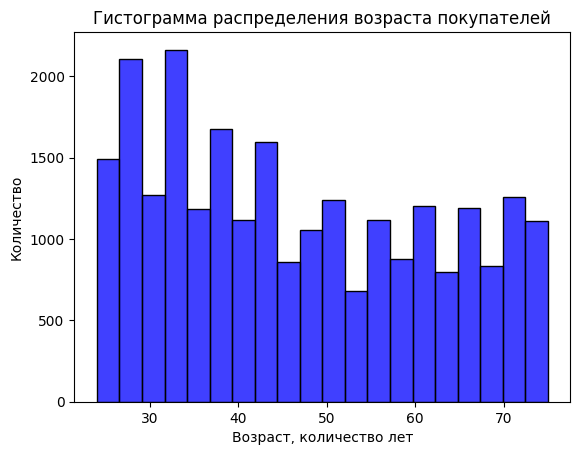

In [ ]:
sns.histplot(age, bins=20, color='blue')
plt.title('Гистограмма распределения возраста покупателей')
plt.xlabel('Возраст, количество лет')
plt.ylabel('Количество')
plt.show()

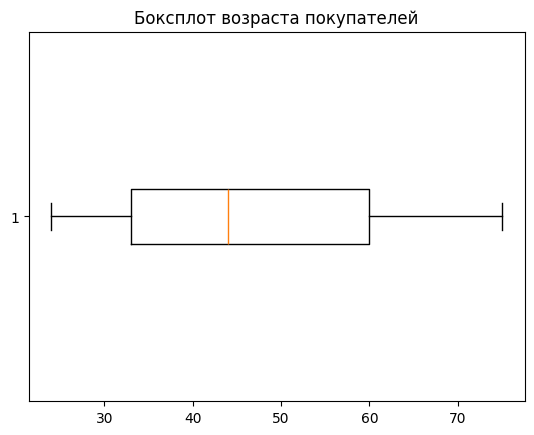

In [ ]:
plt.boxplot(age, vert=False)
plt.title('Боксплот возраста покупателей')
plt.show()

**Выводы:**
1. Минимальный возраст покупателей составляет 24 года, максимальный — 75 лет. Размах значений равен 51 году, что указывает на значительное разнообразие возрастных групп среди покупателей.
2. Нулевые значения: в данных отсутствуют нулевые или отрицательные значения возраста, так как минимальное значение равно 24 годам. Предобработка для устранения некорректных значений не требуется.
3. Средний возраст покупателей (mean) — 46.75 лет, медиана (50%) — 44 года.
Разница между средним и медианой (2.75 года) невелика, что свидетельствует об относительно симметричном распределении данных без сильного перекоса.
4. 25% покупателей моложе 33 лет, а 75% — моложе 60 лет. Это означает, что основная масса покупателей (50% данных) сосредоточена в возрастном диапазоне от 33 до 60 лет. Только 25% покупателей старше 60 лет, что может указывать на меньшую активность старшего поколения.
5. Гистограмма показывает распределение возрастов с пиками в определенных диапазонах (например, между 30 и 50 годами), что может соответствовать наиболее активным покупателям. Распределение имеет небольшой правый хвост (в сторону старших возрастов), что согласуется с небольшим различием между средним и медианным значениями. Выбросов нет, максимальное значение (75 лет) находится в разумных пределах.

**Общий вывод:**

Данные показывают, что основная аудитория кофейни — это покупатели в возрасте 33–60 лет. Это свидетельствует о том, что заведение пользуется популярностью не столько у молодежи (до 30 лет), сколько у людей среднего и старшего возраста. Возможно, это связано с ценовой политикой, атмосферой или локацией, которые больше соответствуют предпочтениям взрослой аудитории.Для привлечения более молодой аудитории (18–30 лет) может потребоваться корректировка ассортимента, маркетинговых активностей или формата заведения.

### идентификатор кофейни (sales_outlet_id)

In [ ]:
df_copy.sales_outlet_id.nunique()
df_copy.sales_outlet_id.unique()

array([3, 5, 8])

Как мы определили ранее, есть 3 кофейни, 2 из них в Москве, одна в Санкт-Петербурге


### общая сумма чека (total)

In [ ]:
total = df_copy.total

In [ ]:
total.describe()

,total
count,24852.000000
mean,299.613802
std,230.478316
min,52.000000
25%,195.000000
50%,243.750000
75%,390.000000
max,23400.000000


In [ ]:
percentile_10_value = total.quantile(0.10)
percentile_25_value = total.quantile(0.25)
percentile_50_value = total.quantile(0.50)
percentile_75_value = total.quantile(0.75)
percentile_90_value = total.quantile(0.90)
print(f'10-й процентиль: {percentile_10_value}',
      f'25-й процентиль: {percentile_25_value}',
      f'50-й процентиль: {percentile_50_value}',
      f'75-й процентиль: {percentile_75_value}',
      f'90-й процентиль: {percentile_90_value}', sep='\n')

10-й процентиль: 162.5
25-й процентиль: 195.0
50-й процентиль: 243.75
75-й процентиль: 390.0
90-й процентиль: 487.5


In [ ]:
# количество объектов, значения затрат по которым превышает 90 процентиль
len(total[total>total.quantile(0.90)])

1886

In [ ]:
len(total[total>total.quantile(0.99)])

232

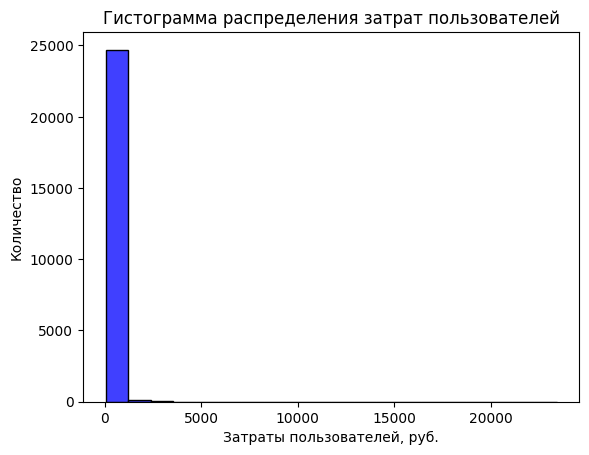

In [ ]:
sns.histplot(total, bins=20, color='blue')
plt.title('Гистограмма распределения затрат пользователей')
plt.xlabel('Затраты пользователей, руб.')
plt.ylabel('Количество')
plt.show()

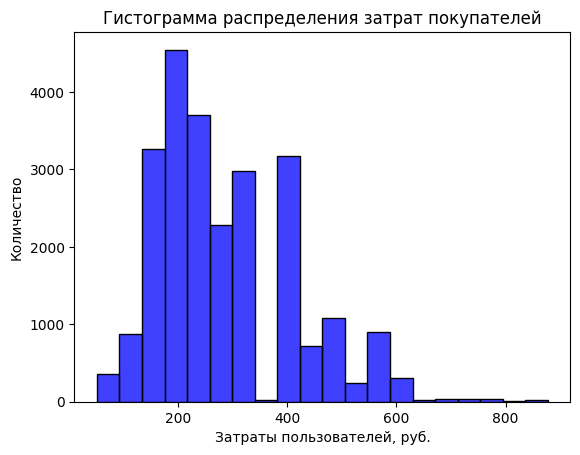

In [ ]:
# построим гистограмму, ограничив 99 процентилем для наглядности
sns.histplot(total[total<total.quantile(0.99)], bins=20, color='blue')
plt.title('Гистограмма распределения затрат покупателей')
plt.xlabel('Затраты пользователей, руб.')
plt.ylabel('Количество')
plt.show()

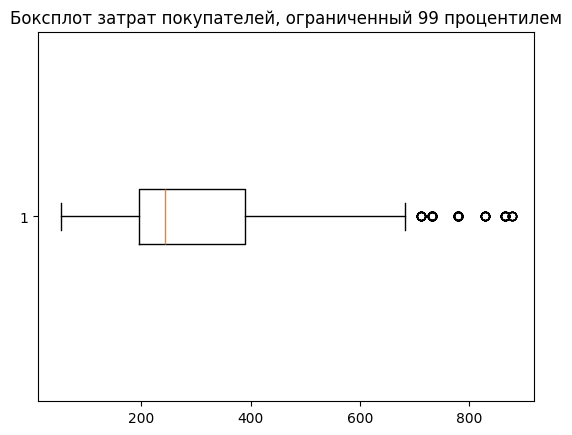

In [ ]:
# построим боксплот, ограничив 99 процентилем для наглядности
plt.boxplot(total[total<total.quantile(0.99)], vert=False)
plt.title('Боксплот затрат покупателей, ограниченный 99 процентилем')
plt.show()

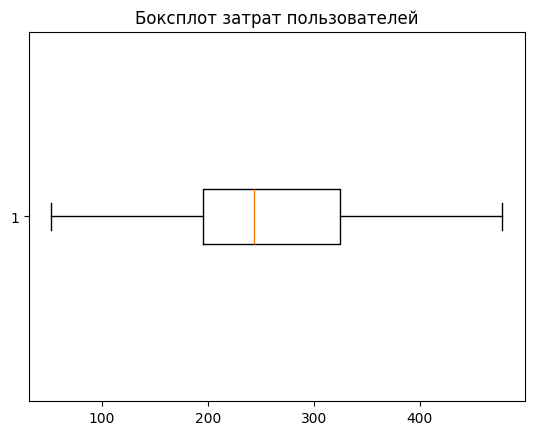

In [ ]:
# построим боксплот, ограничив 90 процентилем для наглядности
plt.boxplot(total[total<total.quantile(0.90)], vert=False)
plt.title('Боксплот затрат пользователей')
plt.show()

**Выводы:**
1. Минимальные затраты: 52 руб, максимальные затраты: 23 400 руб. Размах: 23 348 руб. (крайне широкий, что указывает на наличие аномально высоких значений).

2. Нулевых или отрицательных значений нет (min = 52 руб.), предобработка не требуется.

3. Среднее (mean): 299.61 руб. Медиана (50%): 243.75 руб. Разница между средним и медианой (~56 руб.) получается из-за выбросов, среднее смещено вверх.

4. 25% пользователей тратят ≤ 195 руб.

  50% пользователей тратят ≤ 243.75 руб.

  75% пользователей тратят ≤ 390 руб.

  99% пользователей тратят ~800-900 руб.

Вывод: 90% данных укладываются в разумные для кофейни суммы, а траты выше 800 руб. (1%) выглядят аномально.

5. Графический анализ

  Гистограмма, построенная по всем данным отражает наличие выбросов;

  Гистограмма (ограничена 99-м процентилем): большинство трат сосредоточено в диапазоне 150–500 руб.

  Боксплот (ограничен 99-м процентилем): выбросы начинаются выше ~800 руб. (по "усам" графика). Такие суммы для кофейни выглядят подозрительно (возможны ошибки в данных, корпоративные заказы).

  Для большинства задач (анализ среднего чека, прогнозирование) разумно отсечь 5–10% самых высоких значений, чтобы получить репрезентативную картину. Если выбросы — реальные данные (например, корпоративные заказы), их стоит анализировать отдельно. Для дальшейших исследований я удалю все строки в таблице, где значения total превышают 0.99 процентиль

In [ ]:
threshold = df_copy['total'].quantile(0.99)

In [ ]:
df_copy = df_copy[df_copy['total'] <= threshold]

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24620 entries, 0 to 24851
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    24620 non-null  int64  
 1   product_id        24620 non-null  int64  
 2   product_name      24620 non-null  object 
 3   product_category  24620 non-null  object 
 4   sales_outlet_id   24620 non-null  int64  
 5   store_city        24620 non-null  object 
 6   customer_id       24620 non-null  int64  
 7   gender            24620 non-null  object 
 8   age               24620 non-null  int64  
 9   total             24620 non-null  float64
dtypes: float64(1), int64(5), object(4)
memory usage: 2.1+ MB


Проверка: 24852-232=24620, все правильно

###customer_id

In [ ]:
customer_id = df_copy.customer_id

In [ ]:
customer_id.nunique()

2245

In [ ]:
unique_clients_per_outlet = df_copy.drop_duplicates(subset=['customer_id', 'sales_outlet_id']) \
                             .groupby('sales_outlet_id')['customer_id'].count().reset_index(name='unique_clients')

In [ ]:
unique_clients_per_outlet

,sales_outlet_id,unique_clients
0,3,800
1,5,944
2,8,501


В кофейне Санкт-Петербурга 800 уникальных клиентов
В 2 кофейнях Москвы почти в 2 раза больше - 1445

У нас всего 2245 покупателей во всей сети кофеен

## Категориальные признаки

In [ ]:
df_copy.select_dtypes(include=[object]).columns

Index(['product_name', 'product_category', 'store_city', 'gender'], dtype='object')

### gender

In [ ]:
gender = df_copy.gender
gender.describe()

,gender
count,24620
unique,3
top,женский
freq,10749


In [ ]:
gender_conflicts = df_copy.groupby('customer_id')['gender'].nunique().reset_index(name='unique_genders')
conflicted_customers = gender_conflicts[gender_conflicts['unique_genders'] > 1]

print(f"Клиентов с противоречивым полом: {len(conflicted_customers)}")

Клиентов с противоречивым полом: 0


In [ ]:
customers_gender = df_copy.drop_duplicates(subset=['customer_id'])[['customer_id', 'gender']]

In [ ]:
gender_stats = customers_gender['gender'].value_counts(normalize=True) * 100
print(gender_stats)

gender
женский      43.474388
мужской      32.338530
не указан    24.187082
Name: proportion, dtype: float64


In [ ]:
gender.mode()

,gender
0,женский


In [ ]:
gender.value_counts()

,count
gender,
женский,10749
мужской,8139
не указан,5732


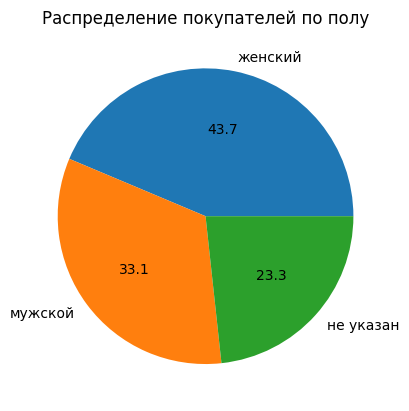

In [ ]:
plt.pie(gender.value_counts(), labels = gender.value_counts().index, autopct='%.1f')
plt.title('Распределение покупателей по полу')
plt.show()

**Выводы:**
1. 3 категории:

  женский — 10 749 (44%)

  мужской — 8 139 (33%)

  не указан — 5 732 (23%) В датасете по признаку пол не указаны значения приблизительно у 23% покупателей. На мой взгляд, удаление таких пользователей исказит общую картину, так как их немало. В дальнейшем планируется сравнивать метрики (средний чек, частоту покупок) по всем трём группам. Если различия между "не указан" и остальными малы — можно объединить с преобладающей группой.
2. Распределение по полу показывает преобладание женщин (43.7%) над мужчинами (33.1%), но не слишком высокое.

### store_city

In [ ]:
city = df_copy.store_city
city.describe()

,store_city
count,24852
unique,2
top,Москва
freq,16259


In [ ]:
city.mode()

,store_city
0,Москва


In [ ]:
city.value_counts()

,count
store_city,
Москва,16091
Санкт-Петербург,8529


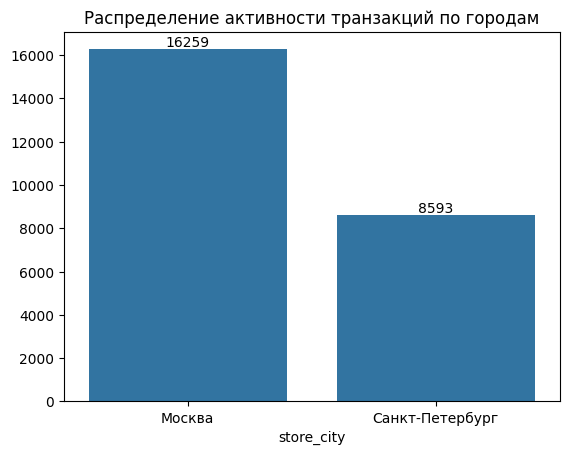

In [ ]:
ax = sns.barplot(y=city.value_counts().values, x=city.value_counts().index)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Распределение активности транзакций по городам')
plt.show()

In [ ]:
id = df_copy.sales_outlet_id

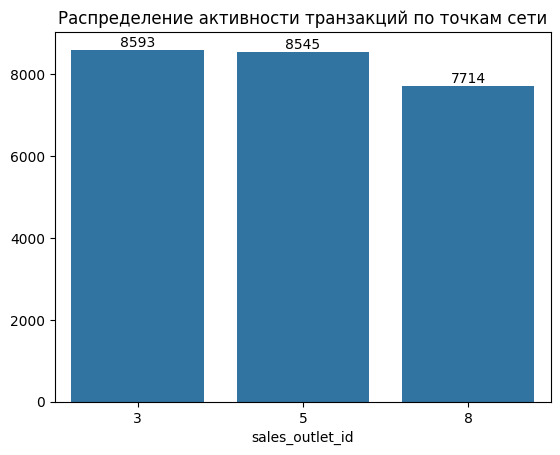

In [ ]:
ax = sns.barplot(y=id.value_counts().values, x=id.value_counts().index)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Распределение активности транзакций по точкам сети')
plt.show()

In [ ]:
unique_clients_сity = df_copy.drop_duplicates(subset=['customer_id', 'store_city']) \
                             .groupby('store_city')['customer_id'].count().reset_index(name='unique_clients')

In [ ]:
unique_clients_сity

,store_city,unique_clients
0,Москва,1445
1,Санкт-Петербург,800


<ipython-input-193-489711622>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


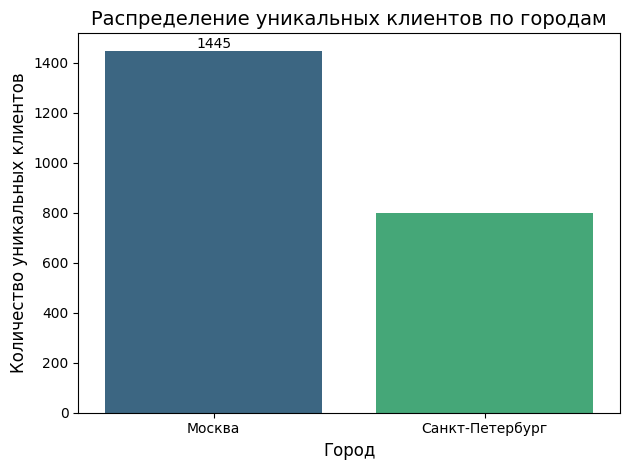

In [ ]:
ax = sns.barplot(
    x='store_city',
    y='unique_clients',
    data=unique_clients_sity,
    palette='viridis'  # Цветовая схема
)

# Добавление подписей значений на столбцы
ax.bar_label(ax.containers[0], fontsize=10, fmt='%d')

# Настройка оформления
plt.title('Распределение уникальных клиентов по городам', fontsize=14)
plt.xlabel('Город', fontsize=12)
plt.ylabel('Количество уникальных клиентов', fontsize=12)
plt.tight_layout()  # Автоматическая настройка отступов

plt.show()

**Выводы:**

1. В данных представлены 2 города:

  Москва — 16 091 проведенных транзакций (65%).

  Санкт-Петербург — 8 529 проведенные транзакции (35%).

2. Наиболее часто встречаемое значение
  
  Москва — доминирующий город, так как 2 точки.

### product_category

In [ ]:
product_category = df_copy.product_category
product_category.describe()

,product_category
count,24852
unique,9
top,Coffee
freq,9948


In [ ]:
product_category.mode()

,product_category
0,Coffee


In [ ]:
product_category.value_counts()

,count
product_category,
Coffee,9948
Tea,7866
Bakery,3780
Drinking Chocolate,1955
Flavours,782
Coffee beans,217
Loose Tea,155
Branded,82
Packaged Chocolate,67


In [ ]:
product_category.value_counts()[:5]

,count
product_category,
Coffee,9948
Tea,7866
Bakery,3780
Drinking Chocolate,1955
Flavours,782


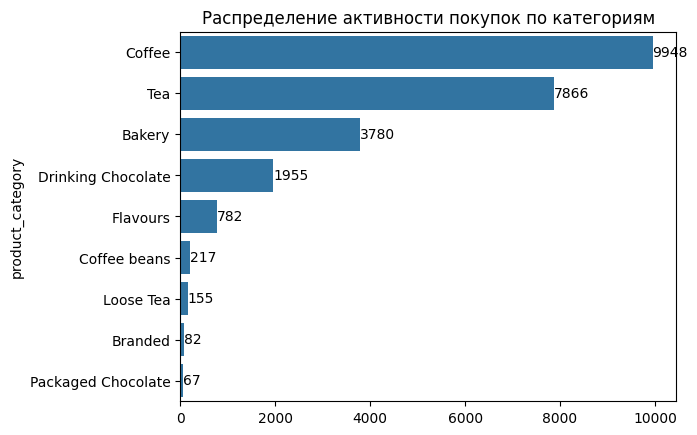

In [ ]:
ax = sns.barplot(y=product_category.value_counts().index[:9], x=product_category.value_counts().values[:9])
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Распределение активности покупок по категориям')
plt.show()

**Выводы:**
1. Всего 9 уникальных категорий;
2. Топ-5 (Coffee, Tea, Bakery, Drinking Chocolate, Flavours).
3. Наиболее часто встречаемые категории:

  Coffee — лидер (9 948 покупок, ~40% от общего числа).

  Tea — второе место (7 866, ~31.6%).

  Bakery — третье место (3 780, ~15.2%).

  Эти три категории составляют ~87% всех покупок, что показывает их ключевую значимость для бизнеса.

## Взаимосвязь количественных признаков

In [ ]:
# при необходимости подгрузить файлы и сохранить данные в переменные
# df_copy = pd.read_excel('shop_users_clean_v2.xlsx')
# df_games = pd.read_csv('df_games_v2.csv')

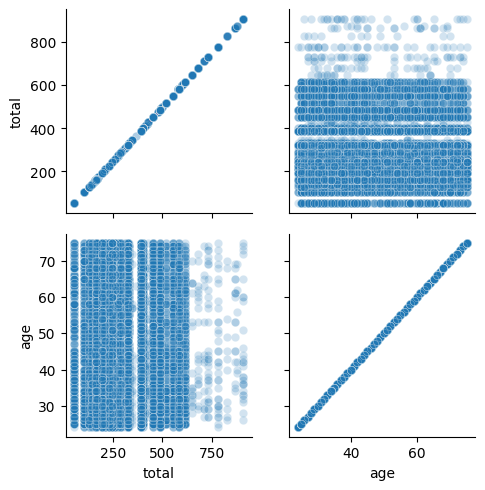

In [ ]:
g = sns.PairGrid(df_copy[['total', 'age']])
g.map(sns.scatterplot, alpha=0.2)
plt.show()

### total - age

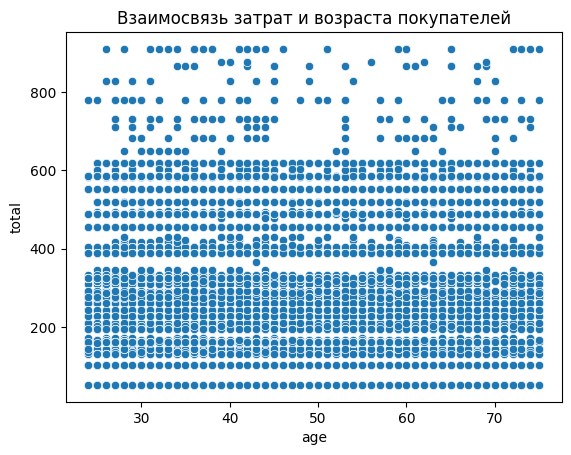

In [ ]:
sns.scatterplot(data=df_copy, x='age', y='total')
plt.title('Взаимосвязь затрат и возраста покупателей')
plt.show()

**Выводы:**
1. По общей диаграмме рассеяния заметно, что общая сумма чека не зависит от возраста покупателей.
2. Попробуем проанализировать зависимость общей суммы чека и возраста с группировкой, чтобы было наглядно

In [ ]:
df_copy['age_group'] = pd.cut(
    df_copy['age'],
    bins=[0, 30, 50, 75],
    labels=['<30', '30-50', '50+']
)

# Расчет среднего чека по группам
age_group_stats = df_copy.groupby('age_group')['total'].agg(['mean', 'median', 'count'])
print(age_group_stats)

                 mean  median  count
age_group                           
<30        288.821664  243.75   4249
30-50      287.704382  243.75  10485
50+        287.554319  243.75   9886


<ipython-input-85-3264865366>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_stats = df_copy.groupby('age_group')['total'].agg(['mean', 'median', 'count'])


<ipython-input-185-742964656>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_copy, x='age_group', y='total', showfliers=False,palette='viridis')


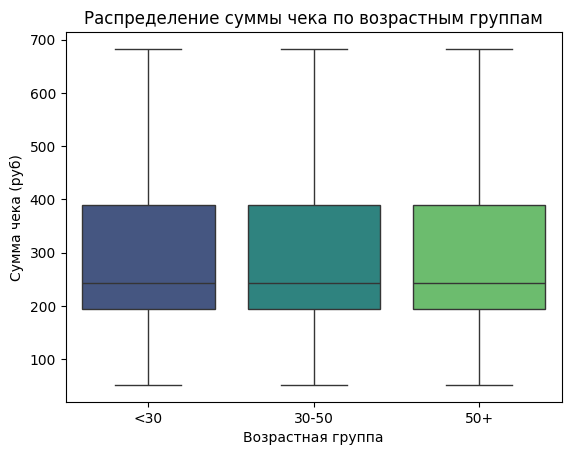

In [ ]:
sns.boxplot(data=df_copy, x='age_group', y='total', showfliers=False,palette='viridis')
plt.title('Распределение суммы чека по возрастным группам')
plt.ylabel('Сумма чека (руб)')
plt.xlabel('Возрастная группа')
plt.show()

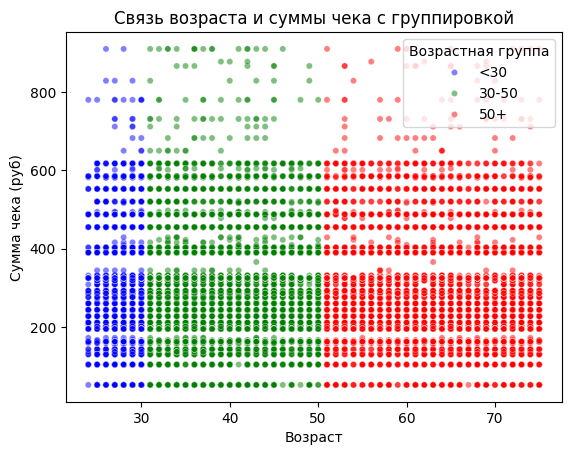

In [ ]:
sns.scatterplot(
    data=df_copy,
    x='age',
    y='total',
    hue='age_group',  # Цвет по группам
    palette={'<30': 'blue', '30-50': 'green', '50+': 'red'},
    alpha=0.5,
    s=20  # Размер точек
)
plt.title('Связь возраста и суммы чека с группировкой')
plt.xlabel('Возраст')
plt.ylabel('Сумма чека (руб)')
plt.legend(title='Возрастная группа')
plt.show()

**Выводы**

По графикам видно, что:

  1. точки распределены равномерно по всем возрастным группам (<30, 30-50, 50+).

  2. нет сильно видимого тренда (например, рост или падение total с увеличением age). Можно сказать, что сумма чека у молодых покупателей в основном от 200 до 400, от 400 до 800 уже меньшее количество в сравнение с более взрослыми клиентами.

### total - age - gender

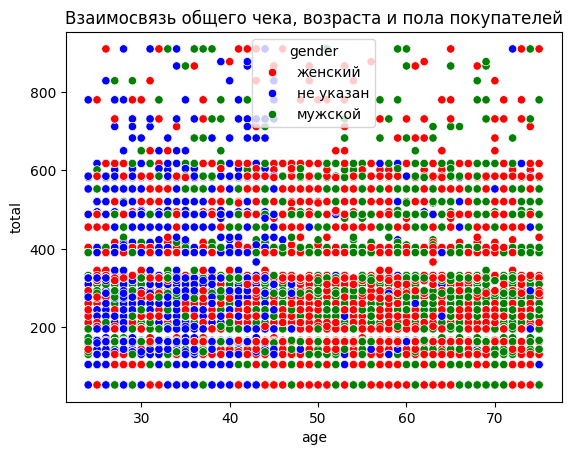

In [ ]:
sns.scatterplot(data=df_copy, x='age', y='total', hue='gender', palette=['r', 'b','g'])
plt.title('Взаимосвязь общего чека, возраста и пола покупателей')
plt.show()

## Взаимосвязь количественных и категориальных признаков

* Категориальные и Непрерывные (total)

age - gender, age - city - gender: анализ аудитории

product_category - total:

Какие категории приносят больше прибыли?

store_city - total:

Сравнение средних чеков в Москве и СПб

gender - total:

Сравнение трат мужчин, женщин и группы "не указан".


* Категориальные и Дискретные

sales_outlet_id - product_category:

В каких точках какие категории популярны

### age - gender

In [ ]:
df_copy.groupby('gender')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
женский,10749.0,49.269327,14.888880,24.0,36.0,49.0,62.0,75.0
мужской,8139.0,50.736208,14.761471,24.0,38.0,51.0,64.0,75.0
не указан,5732.0,36.356595,10.537874,24.0,29.0,34.0,40.0,75.0


<ipython-input-182-3558934655>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='gender', x='age', data=df_copy, palette='viridis')


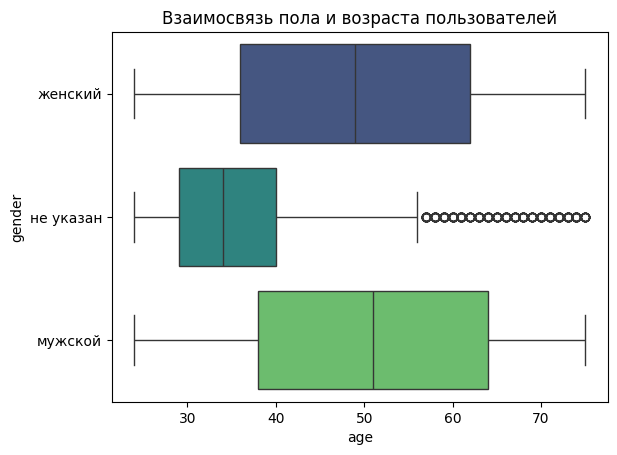

In [ ]:
sns.boxplot(y='gender', x='age', data=df_copy, palette='viridis')
plt.title('Взаимосвязь пола и возраста пользователей')
plt.show()

**Выводы**

1. Женщины: средний возраст: ~49 лет;
  Распределение симметричное (медиана 49, mean ≈ 49.3), охватывает всю выборку (24–75 лет).
2. Мужчины: Средний возраст: ~51 год (чуть старше женщин).
  Распределение: аналогично женскому, но сдвинуто вправо (медиана 51).
3. Не указан: средний возраст: ~36 лет (значительно моложе), то есть по графику видно, что не указывают пол более молодые покупатели

### age - city - gender

In [ ]:
df_copy.groupby('store_city')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
store_city,,,,,,,,
Москва,16091.0,45.101920,14.929444,24.0,32.0,42.0,58.0,75.0
Санкт-Петербург,8529.0,49.853324,14.914199,24.0,37.0,50.0,63.0,75.0


<ipython-input-181-2074371538>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='store_city', x='age', data=df_copy, palette='viridis')


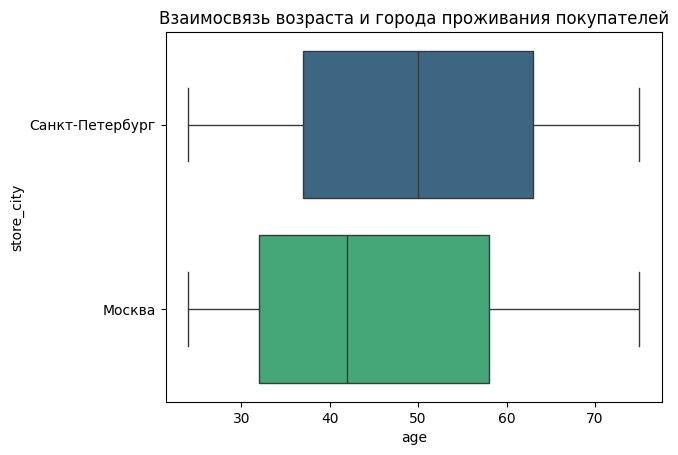

In [ ]:
sns.boxplot(y='store_city', x='age', data=df_copy, palette='viridis')
plt.title('Взаимосвязь возраста и города проживания покупателей')
plt.show()

In [ ]:
df_copy.groupby(['store_city', 'gender'])['age'].describe()

count       mean        std   min   25%   50%  \
store_city      gender                                                      
Москва          женский    6486.0  49.202899  14.796929  24.0  36.0  49.0   
                мужской    4941.0  50.961344  14.752490  24.0  38.0  52.0   
                не указан  4664.0  33.191467   5.688987  24.0  28.0  32.0   
Санкт-Петербург женский    4263.0  49.370396  15.028880  24.0  36.0  49.0   
                мужской    3198.0  50.388368  14.770898  24.0  38.0  51.0   
                не указан  1068.0  50.178839  14.831855  24.0  38.0  51.0   

                            75%   max  
store_city      gender                 
Москва          женский    62.0  75.0  
                мужской    65.0  75.0  
                не указан  37.0  45.0  
Санкт-Петербург женский    62.0  75.0  
                мужской    64.0  75.0  
                не указан  63.0  75.0

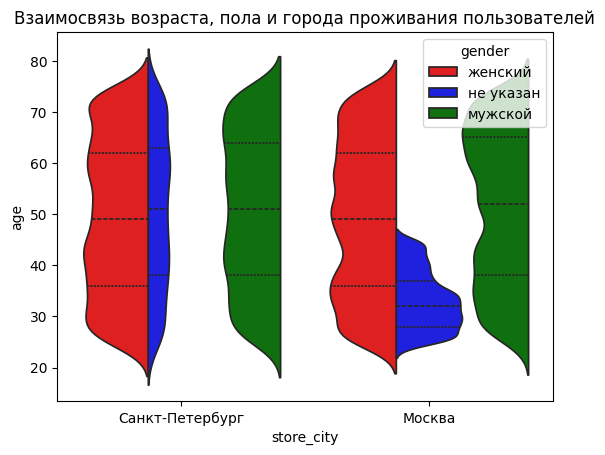

In [ ]:
# скрипичная диаграмма
sns.violinplot(data=df_copy, x='store_city', y='age',
               hue='gender', split=True, inner="quart", palette=['r', 'b','g'])
plt.title('Взаимосвязь возраста, пола и города проживания пользователей')
plt.show()

**Выводы:**
1. Взаимосвязь возраста и города (boxplot)

  * Москва: медиана возраста - 42 года, распределение сдвинуто влево (моложе), 25–75% перцентили — 32–58 лет. Таким образом, в Москве больше молодых покупателей (25% младше 32 лет).

  * Санкт-Петербург: медиана возраста - 50 лет, распределение сдвинуто вправо (старше), 25–75% перцентили — 37–63 года. Таким образом, в Санкт-Петербурге преобладают покупатели 37–63 лет, почти нет "молодежи" (<30 лет).

2. Взаимосвязь возраста, пола и города (violinplot)
  * Женщины в среднем моложе мужчин в Москве, но старше в СПб.

  * Группа "не указан" в Москве большее количество - это молодные люди(~30–35 лет), в Питере распределена более равномерно, меньшее количество.


### gender-total

<ipython-input-180-1794049520>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_copy, x='gender', y='total',palette='viridis')


<Axes: xlabel='gender', ylabel='total'>

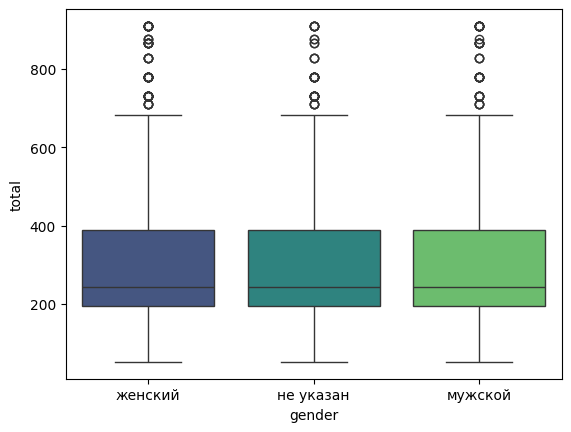

In [ ]:
sns.boxplot(data=df_copy, x='gender', y='total',palette='viridis')

### product_category - total


In [ ]:
product_category = df_copy.product_category
product_category.value_counts()[:3]

,count
product_category,
Coffee,9948
Tea,7866
Bakery,3780


In [ ]:
df_copy.groupby('product_category')["total"].median()

,total
product_category,
Bakery,227.50
Branded,910.00
Coffee,276.25
Coffee beans,650.00
Drinking Chocolate,308.75
Flavours,104.00
Loose Tea,581.75
Packaged Chocolate,494.00
Tea,325.00


In [ ]:
df_copy.groupby('product_category')['total'].sum()

,total
product_category,
Bakery,889266.30
Branded,44200.00
Coffee,2962352.25
Coffee beans,13260.00
Drinking Chocolate,791732.50
Flavours,64116.00
Loose Tea,92985.75
Packaged Chocolate,37791.65
Tea,2190841.25


In [ ]:
category_list =df_copy['product_category'].value_counts()[:3].index
category_list

Index(['Coffee', 'Tea', 'Bakery'], dtype='object', name='product_category')

In [ ]:
df_copy_category_top_3 = df_copy[df_copy['product_category'].isin(category_list)]
df_copy_category_top_3.shape

(21594, 11)

In [ ]:
df_copy_category_top_3.groupby('product_category')["total"].describe()

,count,mean,std,min,25%,50%,75%,max
product_category,,,,,,,,
Bakery,3780.0,235.255635,40.558315,172.25,211.25,227.50,243.75,585.00
Coffee,9948.0,297.783700,125.226080,130.00,195.00,276.25,390.00,828.75
Tea,7866.0,278.520372,105.427702,162.50,195.00,325.00,390.00,780.00


<ipython-input-179-4053683676>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='product_category', y="total", data=df_copy_category_top_3,palette='viridis')


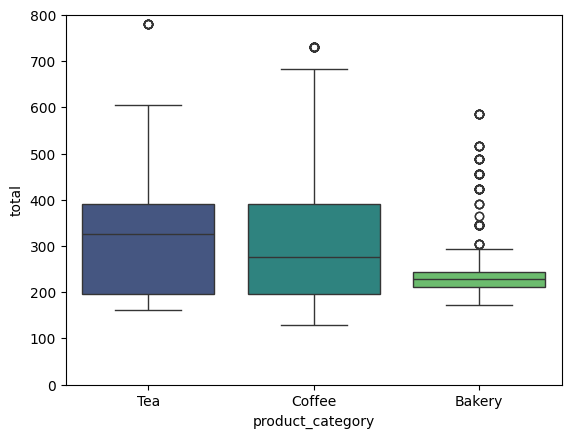

In [ ]:
sns.boxplot(x='product_category', y="total", data=df_copy_category_top_3,palette='viridis')
plt.axis(ymin=0, ymax=800)
plt.show()

1. Coffee имеет самый высокий чек: в среднем, чек для Coffee выше (297.78), чем для Tea (278.52) и Bakery (235.26).
2. Bakery имеет самый низкий  чек: Bakery имеет наименьшее среднее значение (235.26) и медиану (227.5), что может говорить о том, что это в основном небольшие заказы.
3. Наибольший разброс в Coffee: Coffee также имеет самый высокий стандартное отклонение (125.23), что указывает на больший разброс в суммах чеков по сравнению с Tea (105.43) и Bakery (40.56). Это может говорить о том, что заказы кофе могут сильно варьироваться по объему или содержать более дорогие позиции.
4. Высокие выбросы для Bakery: на графике видно большое количество выбросов для категории “Bakery”,то означает, что большинство заказов находятся в узком диапазоне сумм, но иногда бывают значительно более крупные заказы, влияющие на среднее значение.

Итог: в среднем, покупатели тратят больше на кофе, чем на чай или выпечку. Разброс сумм чеков для кофе также больше, чем для чая или выпечки. Чеки для выпечки обычно самые низкие, но иногда встречаются значительные крупные заказы.

### store_city - total

In [ ]:
df_copy.groupby('store_city')['total'].agg(['sum'])

,sum
store_city,
Москва,4665029.85
Санкт-Петербург,2421515.85


Суммарные чеки в Москве, где расположено две кофейни сети, приблизительно в два раза превышают аналогичный показатель в Санкт-Петербурге, где находится одна кофейня. Это соответствует логике, учитывая, что сеть имеет стандартизированные цены на продукцию в обоих городах.

In [ ]:
df_copy.groupby('store_city')["total"].describe()

,count,mean,std,min,25%,50%,75%,max
store_city,,,,,,,,
Москва,16091.0,289.915471,131.779088,52.0,195.0,243.75,390.0,910.0
Санкт-Петербург,8529.0,283.915565,122.760302,52.0,195.0,243.75,390.0,910.0


<ipython-input-178-2158752276>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_copy, x='store_city', y='total',palette='viridis')


<Axes: xlabel='store_city', ylabel='total'>

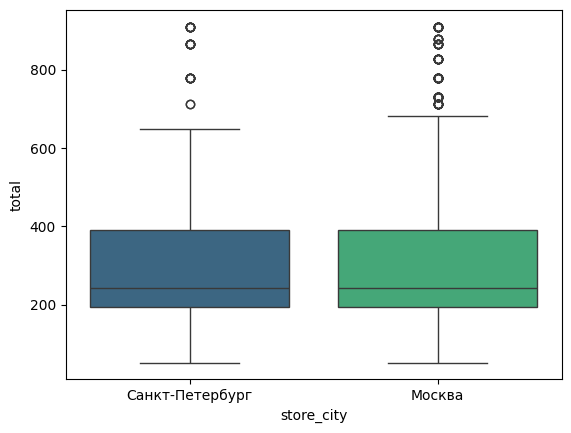

In [ ]:
sns.boxplot(data=df_copy, x='store_city', y='total',palette='viridis')

По графику не видно сильных отличий, проанализируем более детально

Теперь рассмотрим влияние города по категориям

<Axes: xlabel='product_category', ylabel='total'>

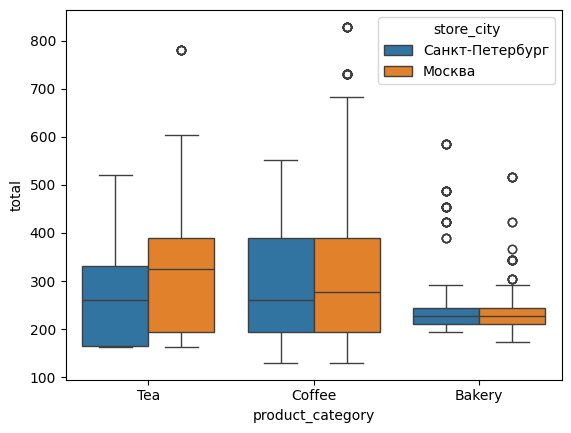

In [ ]:
sns.boxplot(x='product_category', y='total', hue='store_city', data=df_copy_category_top_3)

1. Tea:
  
  Москва: Средний чек (медиана) и диапазон сумм чеков (размер “ящика”) для чая в Москве выше, чем в Санкт-Петербурге. Это говорит о том, что в Москве люди в среднем тратят больше на чай, и диапазон этих трат шире.
2. Coffee:
  
  Москва: Снова, средний чек и общий диапазон чеков для кофе немного выше в Москве, чем в Санкт-Петербурге, хотя различия не столь существенны, как для чая.
  
  Оба города демонстрируют значительный разброс в суммах чеков за кофе, с большим количеством выбросов, указывающих на то, что иногда бывают очень крупные заказы кофе.
3. Bakery:

  Средние чеки и разброс значений практически идентичны для Bakery в обоих городах. Это может означать, что покупательское поведение в отношении выпечки в Москве и Санкт-Петербурге довольно схоже.

  В категории Bakery наблюдается большое количество выбросов в обоих городах, что указывает на наличие более крупных заказов, значительно превышающих стандартные.

Общие выводы:

Москва чаще имеет более высокие чеки: Для чая и кофе наблюдается тенденция к более высоким средним чекам в Москве по сравнению с Санкт-Петербургом.
Bakery - самая “стабильная” категория: Чеки за выпечку демонстрируют наименьшую разницу между городами и наименьший общий разброс (не считая выбросов), что может говорить о более стандартизированном процессе покупки.
Выбросы: Наличие выбросов, особенно в Bakery, может указывать на оптовые закупки или крупные заказы к мероприятиям.

### sales_outlet_id - product_category

3 - кофейня в СПБ
5,8 - кофейни в МСК

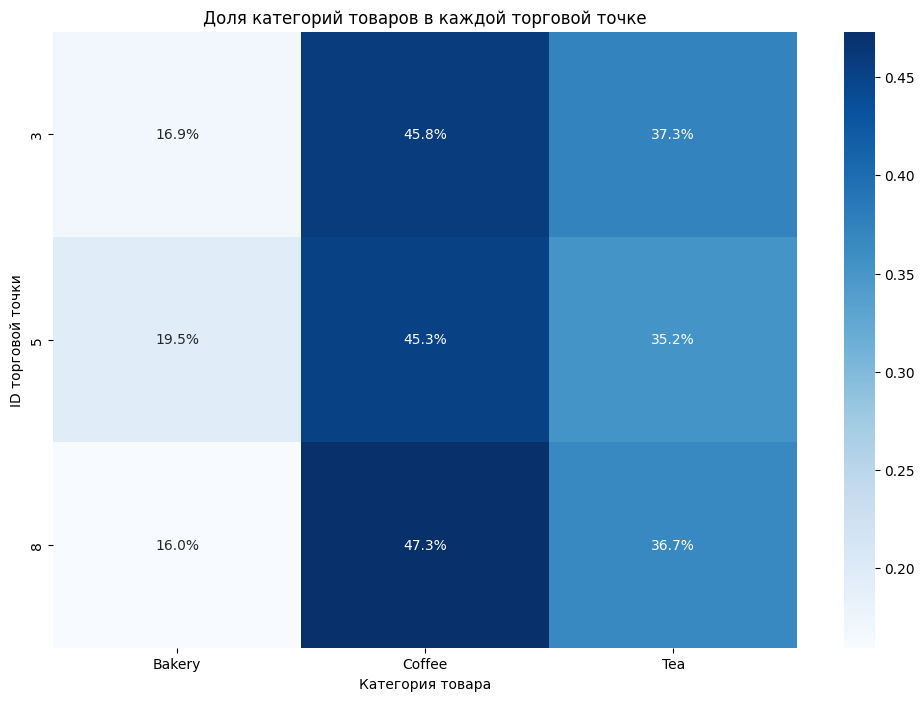

In [ ]:
cross_tab = pd.crosstab(
    index=df_copy['sales_outlet_id'],
    columns=df_copy_category_top_3['product_category'],
    normalize='index'  # Процентное соотношение по строкам
)

# Визуализация тепловой карты
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, annot=True, fmt='.1%', cmap='Blues')
plt.title('Доля категорий товаров в каждой торговой точке')
plt.xlabel('Категория товара')
plt.ylabel('ID торговой точки')
plt.show()

На всех трех торговых точках сети кофеен доминирует категория "Кофе", составляя наибольшую долю выручки. При этом, в кофейне с идентификатором 5 наблюдается повышенный спрос на "Выпечку" по сравнению с остальными точками. “Кофе” и “Чай” являются ведущими категориями товаров в сети, что является логичным.

### customer_id - product_category

In [ ]:
category_clients = df_copy.drop_duplicates(subset=['customer_id', 'product_category']) \
                         .groupby('product_category')['customer_id'].count() \
                         .reset_index(name='unique_clients') \
                         .sort_values('unique_clients', ascending=False)

<ipython-input-205-490357287>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


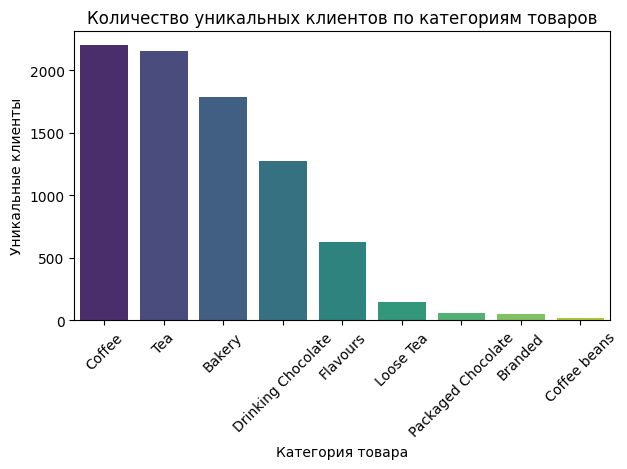

In [ ]:
sns.barplot(
    x='product_category',
    y='unique_clients',
    data=category_clients,
    palette='viridis'
)
plt.title('Количество уникальных клиентов по категориям товаров')
plt.xlabel('Категория товара')
plt.ylabel('Уникальные клиенты')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Кофе, чай и выпечка, как уже было получено ранее, 3 самые популярные категории товаров, они наиболее значимы для бизнеса.

## Взаимосвязь категориальных признаков

gender - product_category:

Что ищем: Например, женщины чаще покупают Tea, а мужчины — Coffee.

store_city - product_category:

Сравнение структуры продаж в Москве и СПб.

age_category (группа,созданная из age) - product_category:

Анализ предпочтений

### age_category - gender

In [ ]:
# выделим 4 категории возраста и запишем в отдельный столбец датафрейма
def age_to_category(age):
    '''Переводит цифровое значение возраста в категориальное по указанным критериям.
       Возвращает категорию'''
    if age < 31:
        age_category = '16-30'
    elif age < 51:
        age_category = '31-50'
    else:
        age_category = '51 и выше'
    return age_category

In [ ]:
df_copy['age_category'] = df_copy['age'].apply(age_to_category)
df_copy.head()

,transaction_id,product_id,product_name,product_category,sales_outlet_id,store_city,customer_id,gender,age,total,age_group,age_category
0,0,52,Traditional Blend Chai Rg,Tea,3,Санкт-Петербург,558,женский,42,162.50,30-50,31-50
1,1,27,Brazilian Lg,Coffee,3,Санкт-Петербург,781,не указан,34,455.00,30-50,31-50
2,2,46,Serenity Green Tea Rg,Tea,3,Санкт-Петербург,788,не указан,30,325.00,<30,16-30
3,3,23,Our Old Time Diner Blend Rg,Coffee,3,Санкт-Петербург,683,женский,26,325.00,<30,16-30
4,4,34,Jamaican Coffee River Sm,Coffee,3,Санкт-Петербург,99,мужской,58,159.25,50+,51 и выше


<ipython-input-206-2760313978>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=age_category.value_counts().index, y=age_category.value_counts().values,


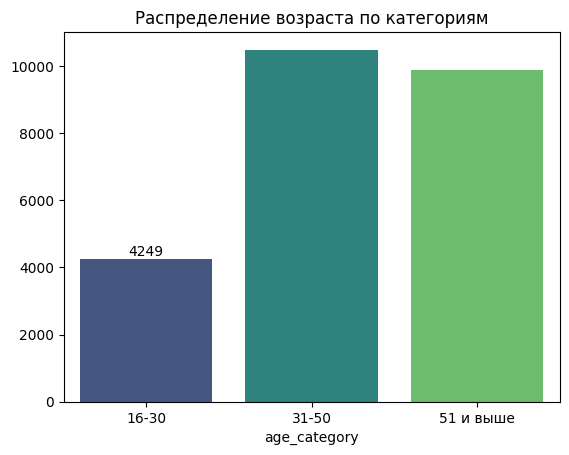

In [ ]:
age_category = df_copy.age_category
# с учетом сортировки по наименованию категорий
ax = sns.barplot(x=age_category.value_counts().index, y=age_category.value_counts().values,
                order=sorted(df_copy.age_category.unique()),palette='viridis')
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Распределение возраста по категориям')
plt.show()

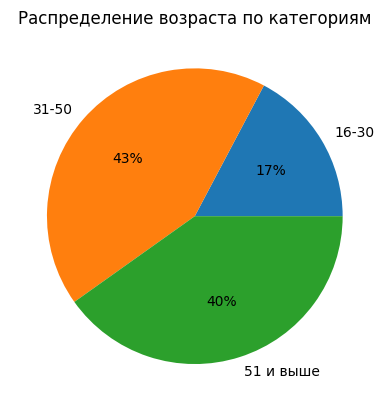

In [ ]:
# с учетом сортировки по наименованию категорий
data_for_pie = age_category.value_counts().sort_index()
ax = plt.pie(x=data_for_pie, labels=data_for_pie.index, autopct='%.0f%%')
plt.title('Распределение возраста по категориям')
plt.show()

In [ ]:
# дополнительно добавим расчет модального значения
df_copy.groupby('age_category')['age'].describe().join(
df_copy.groupby('age_category')['age'].agg([pd.Series.mode]))

,count,mean,std,min,25%,50%,75%,max,mode
age_category,,,,,,,,,
16-30,4249.0,27.378677,1.807061,24.0,26.0,27.0,29.0,30.0,27
31-50,10485.0,39.321221,5.549542,31.0,34.0,39.0,44.0,50.0,34
51 и выше,9886.0,62.949525,7.146744,51.0,57.0,63.0,69.0,75.0,68


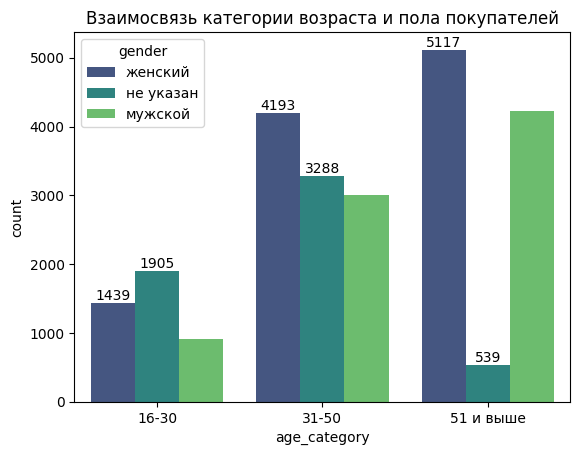

In [ ]:
# с учетом сортировки по наименованию категорий
ax = sns.countplot(data=df_copy, x='age_category', hue='gender', palette='viridis',
                  order=sorted(df_copy.age_category.unique()))
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
plt.title('Взаимосвязь категории возраста и пола покупателей')
plt.show()

**Выводы:**
1. По итогу разделения пользователей по 3 группам возраста (16-30, 31-50, 50 и выше), стало очевидно, что больше всего пользователей в категории 31-50 лет (43%), не менее многочисленная категория выше 50 лет (40%), 26-35 лет (21%). В категории до 30 лет всего 17%,что говорит о меньшей активности молодой аудитории.
2. что среди клиентов преобладают женщины, поэтому можно влиять на ассортимент (например, акцент на десерты или менее крепкие напитки).


### age_category - product_category

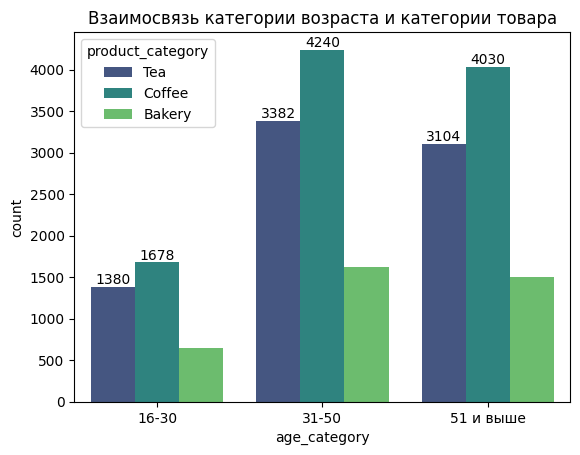

In [ ]:
ax = sns.countplot(data=df_copy, x='age_category', hue=df_copy_category_top_3['product_category'], palette='viridis',
                  order=sorted(df_copy.age_category.unique()))
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
plt.title('Взаимосвязь категории возраста и категории товара')
plt.show()

* Кофе (Coffee) — самая популярная категория во всех возрастных группах, особенно среди людей 31–50 лет (4,240 покупок).

* Чай (Tea) имеет сопоставимый спрос, но уступает кофе.

Возрастные предпочтения:

16–30 лет:

- Наименьшая активность

31–50 лет:

- Пик потребления по всем категориям:

Вывод: Основная аудитория — работающие люди, совмещающие кофе с перекусами.

51 и выше:

- Спрос немного ниже, чем у возрастной группы 31-50, но тоже значим
В целом, графики для каждой возрастной группы имеет единый вид, говорящий о том, что кофе - самый популярный продукт, далее идет чай, далее выпечка.

### age_category - city

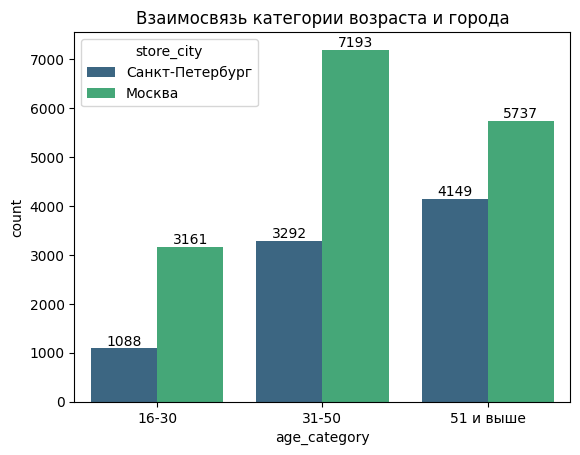

In [ ]:
ax = sns.countplot(data=df_copy, x='age_category', hue='store_city', palette='viridis',
                  order=sorted(df_copy.age_category.unique()))
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
plt.title('Взаимосвязь категории возраста и города')
plt.show()

Согласно построенному графику, в Санкт-Петербурге доля старшей возрастной группы (51+) выше, чем в Москве, где основную аудиторию составляют посетители 31-50 лет."

### gender - product_category

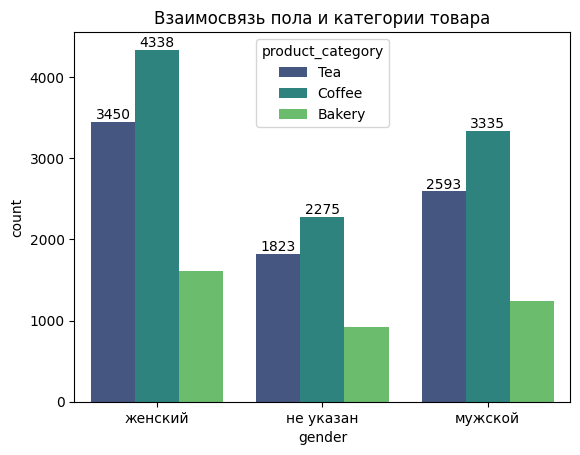

In [ ]:
ax = sns.countplot(data=df_copy, x='gender', hue=df_copy_category_top_3['product_category'], palette='viridis')
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
plt.title('Взаимосвязь пола и категории товара')
plt.show()

### store_city - product_category

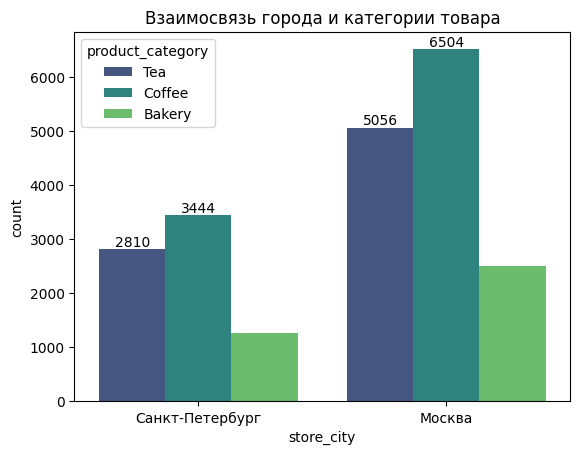

In [ ]:
ax = sns.countplot(data=df_copy, x='store_city', hue=df_copy_category_top_3['product_category'], palette='viridis')
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
plt.title('Взаимосвязь города и категории товара')
plt.show()

***Аналитические цели***:
1. определить текущую структуру продаж по сети кофеен;
2. выявить наиболее прибыльные категории продукции;
3. исследовать целевую аудиторию

**I. Общие выводы по датасету:**
1. Был представлен датасет с выгруженной информацией о транзакциях, товарах и клиентах сети коеен из CRM-системы в формате CSV, содержащий 24909 строк и 6 столбцов.
2. Предобработка данных включала в себя: исключение нерелевантных признаков и объектов, дубликатов, распаковку и форматирование данных, расчет дополнительных признаков.
3. По итогу предобработки сохранен датасет для последующего анализа в формате .xlsx;
4. Дополнительно в процессе анализа была произведена группировка значений возраста по 3 категориям.

**II. Аналитические цели (ключевые выводы)**

**1-2. Анализ структуры продаж + наиболее прибыльные категории продукции**

Топ-3 категорий по выручке:

- Кофе — лидер продаж (средний чек ~276 руб.).

- Чай — средний чек немного выше (~325 руб.).

- Выпечка — низкий средний чек (~227 руб.), стабильно невысокий объем покупок (наибольший спрос на выпечку в кофейне с ID=5).

Категории от которых можно отказаться:

- Loose Tea (рассыпной чай)

- Packaged Chocolate (шоколад в упаковке)

- Branded	(брендовая, фирменая продукция)

- Coffee beans (кофейные зерна)

Местоположение:

Москва генерирует 65% транзакций (2 точки), Санкт-Петербург — 35% (1 точка).

На 1 кофейню в СПб приходится больше клиентов, чем в Москве, что указывает на потенциал для расширения в Питере.

Средний чек в Москве немного выше, чем в Питере, но значимого отличия нет.

Рекомендации:

- Дополнительно проанализировать ассортимент кофе и чая, так как это самые востребованные категории

**3. Анализ целевой аудитории**

Возраст:

Основные клиенты — 31–50 лет (43%) и 50+ (40%). Молодежь (до 30 лет) — всего 17%.

В Москве клиенты моложе (медиана — 42 года), в СПб — старше (медиана — 50 лет).
Можно сделать вывод, что ассортимент продукции / интерьер и т.п. привлекают более взрослую аудиторию.

Пол:

Женщины составляют 44%, мужчины — 33%, 23% не указали пол (более молодая аудитория).

Женщины демонстрируют более высокую покупательскую активность. Анализ топ-3 популярных категорий не выявляет преобладания мужского спроса на какую-то категорию, поскольку во всех случаях лидируют женщины.Поэтому можно влиять на ассортимент (например, акцент на десерты или менее крепкие напитки).

Рекомендации по целевой аудитории для новых точек:

- Стоит обратить внимание на привлечение более молодой аудитории (студентов). Для этого можно запустить рекламу в соцсетях для аудитории 20–40 лет, внедрить программу лояльности с бонусами за повторные покупки, скидки для студентов, если такого нет. Также можно добавить ассортимент, ориентированный на молодежь.

Если у заказчика нет цели привлечения молодой аудитории, то  подход ко взрослой аудитории должен быть консервативным, основанным на ценностях надежности, полезности и простоте.
